# **02477 Bayesian Machine Learning | Comprehensive scripts and code examples**



---

In [1]:
# Standard imports used throughout the notebook
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm, beta as beta_dist, binom, multivariate_normal
from scipy.special import expit as sigmoid  # sigmoid = logistic function

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 4)})
print('Imports OK')

Imports OK


---

<a id='week1'></a>

<div class="alert alert-block alert-info">

### **Week 1 | foundations & beta-binomial model**

Bayesian machine learning, the binominal model, maximum likelihood estimation (MLE), bayesian inference, beta-binomial model
</div>

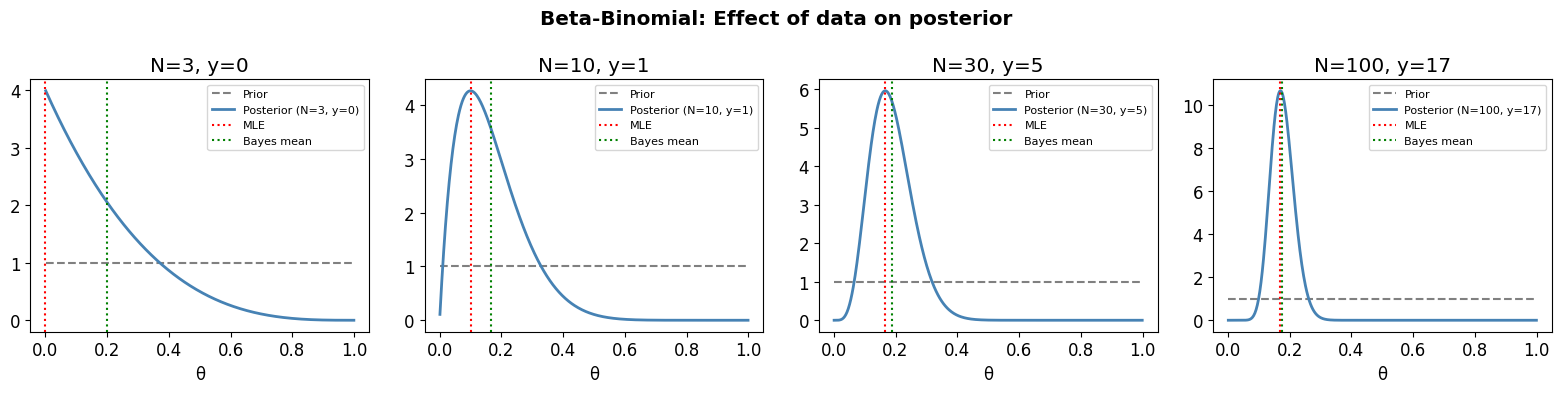

As N grows, posterior concentrates near the true value and MLE ≈ Bayes mean.


In [3]:
# Week 1 demo: beta-binomial bayesian updating
theta_grid = np.linspace(0.001, 0.999, 500)

# Prior: Beta(1,1) = Uniform
a0, b0 = 1, 1

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
datasets = [(0, 3), (1, 10), (5, 30), (17, 100)]  # (heads, total)

for ax, (y, N) in zip(axes, datasets):
    a_post = y + a0
    b_post = (N - y) + b0
    prior_pdf = beta_dist.pdf(theta_grid, a0, b0)
    post_pdf  = beta_dist.pdf(theta_grid, a_post, b_post)
    
    ax.plot(theta_grid, prior_pdf, '--', label='Prior', color='gray')
    ax.plot(theta_grid, post_pdf, label=f'Posterior (N={N}, y={y})', color='steelblue', lw=2)
    ax.axvline(y/N if N>0 else 0, color='red', linestyle=':', label='MLE')
    ax.axvline(a_post/(a_post+b_post), color='green', linestyle=':', label='Bayes mean')
    ax.set_xlabel('θ'); ax.set_title(f'N={N}, y={y}')
    ax.legend(fontsize=8)

fig.suptitle('Beta-Binomial: Effect of data on posterior', fontweight='bold')
plt.tight_layout()
plt.show()
print('As N grows, posterior concentrates near the true value and MLE ≈ Bayes mean.')

<a id='week2'></a>

<div class="alert alert-block alert-info">

### **Week 2 | predictors, plug-in & grid approximation**

Probabilistic machine learning, plug-in approximation, grid approximation, non-conjugate models, logistic regression

</div>

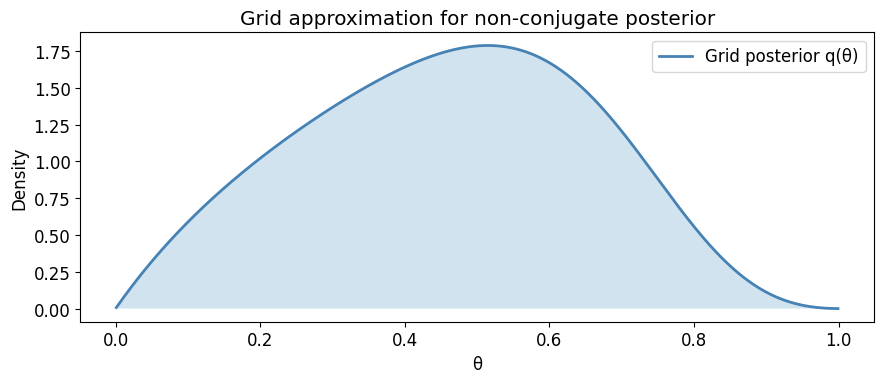

Posterior mean:          0.461
95% credibility interval: [0.089, 0.817]


In [4]:
# Week 2 demo: grid approximation - 1D non-conjugate example
from scipy.stats import norm as gaussian

# Observed data
y_obs = np.array([0, 0, 1])  # 1 click out of 3 views
N, n_clicks = len(y_obs), y_obs.sum()

# Grid
theta_grid = np.linspace(0.001, 0.999, 1000)

# Non-standard prior: p(theta) ∝ exp(sin(π*theta²)) (non-conjugate)
log_prior = np.sin(np.pi * theta_grid**2)
log_likelihood = n_clicks * np.log(theta_grid) + (N - n_clicks) * np.log(1 - theta_grid)

log_unnorm_post = log_prior + log_likelihood
log_unnorm_post -= log_unnorm_post.max()  # numerical stability
unnorm_post = np.exp(log_unnorm_post)
q = unnorm_post / (unnorm_post.sum() * (theta_grid[1] - theta_grid[0]))  # normalise

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(theta_grid, q, color='steelblue', lw=2, label='Grid posterior q(θ)')
ax.fill_between(theta_grid, q, alpha=0.2)
ax.set_xlabel('θ'); ax.set_ylabel('Density')
ax.set_title('Grid approximation for non-conjugate posterior')
ax.legend()
plt.tight_layout(); plt.show()

# Posterior mean and 95% credibility interval
dtheta = theta_grid[1] - theta_grid[0]
post_mean = np.sum(theta_grid * q) * dtheta
cdf = np.cumsum(q) * dtheta
l95 = theta_grid[np.searchsorted(cdf, 0.025)]
u95 = theta_grid[np.searchsorted(cdf, 0.975)]
print(f'Posterior mean:          {post_mean:.3f}')
print(f'95% credibility interval: [{l95:.3f}, {u95:.3f}]')

<a id='week3'></a>

<div class="alert alert-block alert-info">

### **Week 3 | bayesian linear regression**

Bayesian linear regression, posterior predictive distribution, hyperparameters

</div>

MAP estimate:      w0=0.928, w1=1.421
Posterior std:     σ0=0.519, σ1=0.431


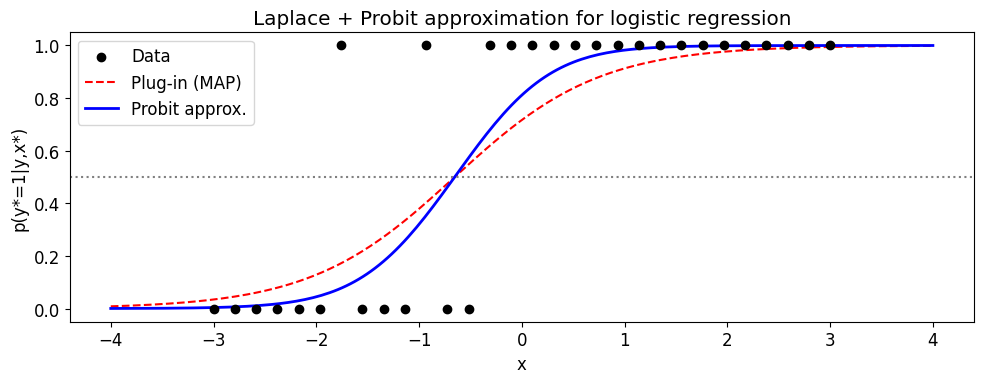

In [5]:
# Week 3 Demo: Laplace approximation for logistic regression
from scipy.optimize import minimize

np.random.seed(42)
# Synthetic binary data
N = 30
x = np.linspace(-3, 3, N)
w_true = np.array([0.5, 1.5])
Phi = np.column_stack([np.ones(N), x])   # design matrix [1, x]
p_true = sigmoid(Phi @ w_true)
y = (np.random.rand(N) < p_true).astype(float)

alpha = 1.0  # prior precision

def neg_log_joint(w):
    f = Phi @ w
    ll = np.sum(y * np.log(sigmoid(f) + 1e-10) + (1-y) * np.log(1 - sigmoid(f) + 1e-10))
    lp = -0.5 * alpha * w @ w
    return -(ll + lp)

res = minimize(neg_log_joint, np.zeros(2), method='BFGS')
w_map = res.x

# Hessian → posterior covariance
from scipy.optimize import approx_fprime
f_map = Phi @ w_map
pi = sigmoid(f_map)
W_diag = pi * (1 - pi)  # Bernoulli second derivative weights
H_neg = Phi.T @ np.diag(W_diag) @ Phi + alpha * np.eye(2)
S = np.linalg.inv(H_neg)  # posterior covariance

print(f'MAP estimate:      w0={w_map[0]:.3f}, w1={w_map[1]:.3f}')
print(f'Posterior std:     σ0={np.sqrt(S[0,0]):.3f}, σ1={np.sqrt(S[1,1]):.3f}')

# Predict using probit approximation
x_star = np.linspace(-4, 4, 200)
Phi_star = np.column_stack([np.ones_like(x_star), x_star])
mu_f = Phi_star @ w_map
var_f = np.diag(Phi_star @ S @ Phi_star.T)
p_pred_probit = norm.cdf(mu_f / np.sqrt(1 + np.pi/8 * var_f))

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x, y, zorder=5, label='Data', color='k')
ax.plot(x_star, sigmoid(Phi_star @ w_map), 'r--', label='Plug-in (MAP)')
ax.plot(x_star, p_pred_probit, 'b-', lw=2, label='Probit approx.')
ax.axhline(0.5, color='gray', linestyle=':')
ax.set_xlabel('x'); ax.set_ylabel('p(y*=1|y,x*)')
ax.set_title('Laplace + Probit approximation for logistic regression')
ax.legend(); plt.tight_layout(); plt.show()

In [15]:
import numpy as np

# Bonus B Demo: Linear Gaussian chai

# Example: 2x2 system
A     = np.array([[0.8, 0.1], [0.0, 0.9]])
Sigma = np.eye(2)

# p(x2) = N(0, A Σ A^T + Σ)
Cov_x2 = A @ Sigma @ A.T + Sigma
print('Cov[x2] ='); print(Cov_x2.round(4))

# p(x3) = N(0, A²Σ(A²)^T + AΣA^T + Σ)
A2 = A @ A
Cov_x3 = A2 @ Sigma @ A2.T + A @ Sigma @ A.T + Sigma
print('\nCov[x3] ='); print(Cov_x3.round(4))

# p(x1|x2=obs) via conditioning formula
x2_obs = np.array([1.0, 0.5])
Sigma12 = Sigma @ A.T          # Cov(x1, x2)
mu_cond = Sigma12 @ np.linalg.solve(Cov_x2, x2_obs)
Sigma_cond = Sigma - Sigma12 @ np.linalg.solve(Cov_x2, Sigma12.T)
print(f'\np(x1 | x2={x2_obs}):')
print(f'  Mean = {mu_cond.round(4)}')
print(f'  Cov  ='); print(Sigma_cond.round(4))

Cov[x2] =
[[1.65 0.09]
 [0.09 1.81]]

Cov[x3] =
[[2.0885 0.2277]
 [0.2277 2.4661]]

p(x1 | x2=[1.  0.5]):
  Mean = [0.4741 0.2814]
  Cov  =
[[ 0.6111 -0.0269]
 [-0.0269  0.5506]]


<a id='week4'></a>

<div class="alert alert-block alert-info">

### **Week 4 | bayesian classification & laplace approximations**

Bayesian versus classical datasets, bayesian methods for classification, bayesian logistic regression, laplace approximations, the posterior predictive distribution

</div>

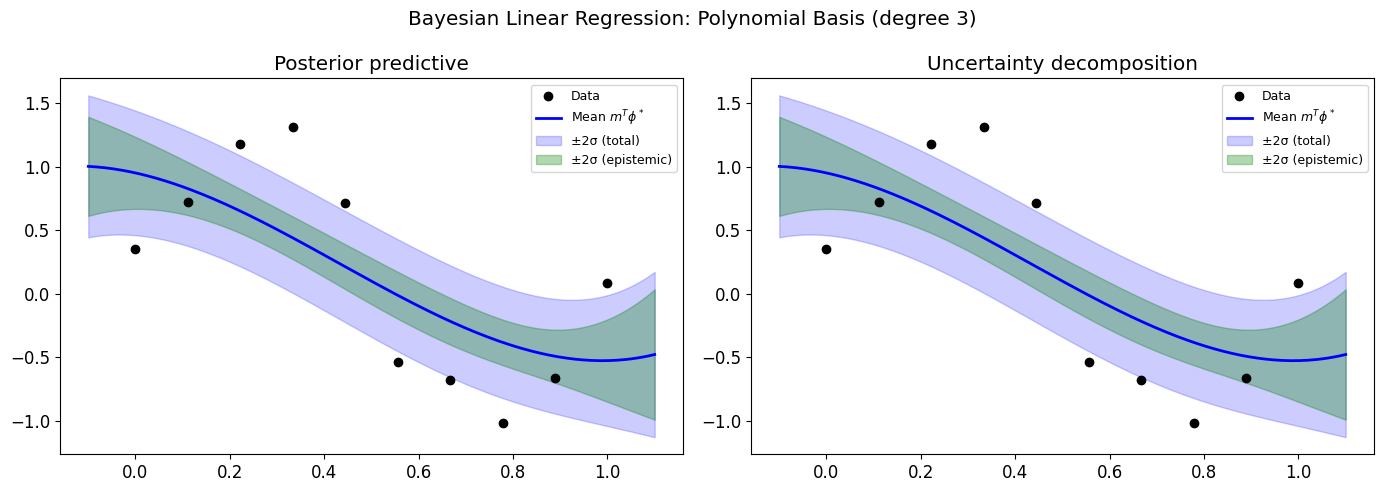

Green = epistemic uncertainty (reduces with more data)
Blue  = total (epistemic + aleatoric = σ² noise)


In [6]:
# Week 4 demo: bayesian linear regression with uncertainty
np.random.seed(0)

# Data
N = 10
x_train = np.linspace(0, 1, N)
y_train = np.sin(2 * np.pi * x_train) + 0.2 * np.random.randn(N)

# Feature map: polynomial degree 3
degree = 3
def phi(x, deg=degree):
    return np.column_stack([x**d for d in range(deg+1)])

Phi_train = phi(x_train)
alpha, beta = 0.5, 25.0  # prior precision, noise precision

# Posterior
S_inv = alpha * np.eye(degree+1) + beta * Phi_train.T @ Phi_train
S = np.linalg.inv(S_inv)
m = beta * S @ Phi_train.T @ y_train

# Predictions
x_star = np.linspace(-0.1, 1.1, 200)
Phi_star = phi(x_star)
mu_f = Phi_star @ m
var_f = np.diag(Phi_star @ S @ Phi_star.T)
var_y = var_f + 1/beta
std_y = np.sqrt(var_y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, ['Posterior predictive', 'Uncertainty decomposition']):
    ax.scatter(x_train, y_train, c='k', zorder=5, label='Data')
    ax.plot(x_star, mu_f, 'b-', lw=2, label='Mean $m^T\\phi^*$')
    ax.fill_between(x_star, mu_f - 2*std_y, mu_f + 2*std_y, alpha=0.2, color='blue', label='±2σ (total)')
    ax.fill_between(x_star, mu_f - 2*np.sqrt(var_f), mu_f + 2*np.sqrt(var_f), alpha=0.3, color='green', label='±2σ (epistemic)')
    ax.legend(fontsize=9); ax.set_title(label)

plt.suptitle('Bayesian Linear Regression: Polynomial Basis (degree 3)')
plt.tight_layout(); plt.show()
print('Green = epistemic uncertainty (reduces with more data)')
print('Blue  = total (epistemic + aleatoric = σ² noise)')

<a id='week5'></a>

<div class="alert alert-block alert-info">

### **Week 5 | From parameters to functions**

Prior distribution for function spaces, gaussian process regression, covariance functions, hyperparameters, marginal likelihood

</div>

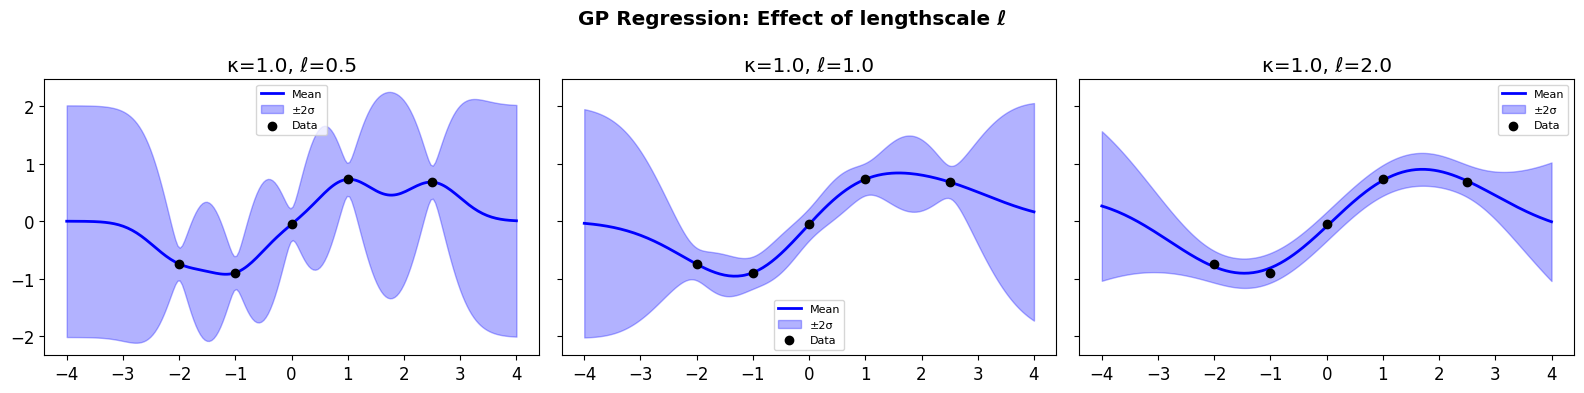

In [7]:
# Week 5 demo: gaussian process regression

def squared_exp_kernel(x1, x2, kappa=1.0, ell=1.0):
    """Squared exponential (RBF) kernel."""
    x1, x2 = np.atleast_1d(x1), np.atleast_1d(x2)
    diff = x1[:, None] - x2[None, :]
    return kappa**2 * np.exp(-diff**2 / (2 * ell**2))

def gp_predict(x_train, y_train, x_star, kappa=1.0, ell=1.0, sigma=0.1):
    """GP posterior predictive mean and variance."""
    K    = squared_exp_kernel(x_train, x_train, kappa, ell) + sigma**2 * np.eye(len(x_train))
    k_s  = squared_exp_kernel(x_star, x_train, kappa, ell)
    c    = squared_exp_kernel(x_star, x_star, kappa, ell) + sigma**2 * np.eye(len(x_star))
    L    = np.linalg.cholesky(K)
    alpha_vec = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu   = k_s @ alpha_vec
    v    = np.linalg.solve(L, k_s.T)
    var  = np.diag(c - v.T @ v)
    return mu, var

# Training data
np.random.seed(1)
x_train = np.array([-2, -1, 0, 1, 2.5])
y_train = np.sin(x_train) + 0.1 * np.random.randn(len(x_train))
x_star  = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
params = [(1.0, 0.5), (1.0, 1.0), (1.0, 2.0)]

for ax, (kappa, ell) in zip(axes, params):
    mu, var = gp_predict(x_train, y_train, x_star, kappa=kappa, ell=ell, sigma=0.1)
    std = np.sqrt(var)
    ax.plot(x_star, mu, 'b-', lw=2, label='Mean')
    ax.fill_between(x_star, mu-2*std, mu+2*std, alpha=0.3, color='blue', label='±2σ')
    ax.scatter(x_train, y_train, c='k', zorder=5, label='Data')
    ax.set_title(f'κ={kappa}, ℓ={ell}')
    ax.legend(fontsize=8)

fig.suptitle('GP Regression: Effect of lengthscale ℓ', fontweight='bold')
plt.tight_layout(); plt.show()

In [16]:
import numpy as np
from scipy.stats import norm

# Bonus D: GP classification prior predictive
# 2025 exam Part 4.1 / 4.2 pattern

def k1(x, xp):
    """2025 exam kernel: k1(x,x') = 5*(1 + exp(-0.25*(x-x')²))"""
    return 5 * (1 + np.exp(-0.25 * (x - xp)**2))

x_star = 4
k_star_star = k1(x_star, x_star)
print(f'k(x*,x*) = k1({x_star},{x_star}) = {k_star_star:.4f}')

# Prior predictive p(f*) ~ N(0, k(x*,x*))
print(f'Prior: p(f*) = N(0, {k_star_star:.4f})')

# Prior predictive class probability via probit
mu_f = 0.0   # prior mean is 0
var_f = k_star_star
p_y1_prior = norm.cdf(mu_f / np.sqrt(1 + np.pi/8 * var_f))
print(f'Prior predictive p(y*=1|x*) = {p_y1_prior:.4f}  (always 0.5 when mean=0!)')
print(f'Prior predictive p(y*=0|x*) = {1-p_y1_prior:.4f}')

print()

# ─── Bonus D: MC estimates from MCMC samples ─────────────────────
np.random.seed(42)
# Simulating 2025 exam Part 5 pattern:  (z,x) ~ N([1,0], [[1,0.5],[0.5,5]])
mu_zx = np.array([1.0, 0.0])
Sigma_zx = np.array([[1.0, 0.5],[0.5, 5.0]])
samples = np.random.multivariate_normal(mu_zx, Sigma_zx, size=6000)
z_s, x_s = samples[:,0], samples[:,1]

E_z_minus_x_sq = np.mean((z_s - x_s)**2)
prob_x_lt_1    = np.mean(x_s < 1.0)
print(f'E[(z-x)²]  ≈ {E_z_minus_x_sq:.2f}  (true = Var[z-x] + (E[z-x])²  = {Sigma_zx[0,0]-2*Sigma_zx[0,1]+Sigma_zx[1,1] + (mu_zx[0]-mu_zx[1])**2:.2f})')
print(f'P(x < 1)   ≈ {prob_x_lt_1:.2f}   (true = Φ((1-{mu_zx[1]})/√{Sigma_zx[1,1]}) = {norm.cdf((1-mu_zx[1])/np.sqrt(Sigma_zx[1,1])):.2f})')

k(x*,x*) = k1(4,4) = 10.0000
Prior: p(f*) = N(0, 10.0000)
Prior predictive p(y*=1|x*) = 0.5000  (always 0.5 when mean=0!)
Prior predictive p(y*=0|x*) = 0.5000

E[(z-x)²]  ≈ 6.05  (true = Var[z-x] + (E[z-x])²  = 6.00)
P(x < 1)   ≈ 0.68   (true = Φ((1-0.0)/√5.0) = 0.67)


<a id='week6'></a>

<div class="alert alert-block alert-info">

### **Week 6 | GP classification & advanced kernels**

Covariance functions, gaussian processes in practice, gaussian process classification, neural networks for probabilistic modelling
</div>

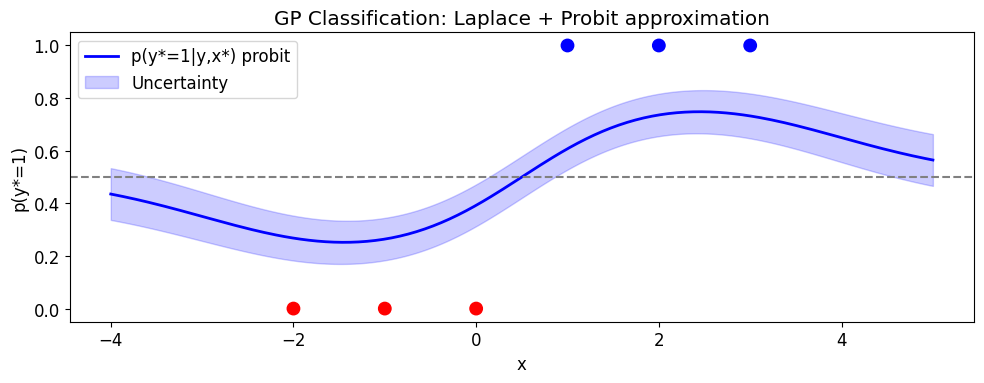

In [8]:
# Week 6 Demo: GP Classification with Laplace approximation
from scipy.optimize import minimize

def gp_laplace_classification(x_train, y_train, kappa=1.0, ell=1.0, n_iter=50):
    """Simple Laplace approximation for GP classification."""
    N = len(x_train)
    K = squared_exp_kernel(x_train, x_train, kappa, ell) + 1e-6 * np.eye(N)
    
    def log_joint(f):
        sigma_f = sigmoid(f)
        ll = np.sum(y_train * np.log(sigma_f + 1e-12) + (1-y_train) * np.log(1-sigma_f+1e-12))
        lp = -0.5 * f @ np.linalg.solve(K, f)
        return -(ll + lp)
    
    res = minimize(log_joint, np.zeros(N), method='L-BFGS-B')
    f_map = res.x
    
    # Hessian
    pi = sigmoid(f_map)
    Lambda = np.diag(pi * (1 - pi))
    S = np.linalg.inv(np.linalg.inv(K) + Lambda)
    
    return f_map, S, K

# Data
np.random.seed(7)
x_train = np.array([-2, -1, 0, 1, 2, 3])
y_train = np.array([0, 0, 0, 1, 1, 1], dtype=float)

f_map, S, K = gp_laplace_classification(x_train, y_train, kappa=1.0, ell=1.5)
x_star = np.linspace(-4, 5, 200)

# Predictive for f*
k_s = squared_exp_kernel(x_star, x_train, kappa=1.0, ell=1.5)
K_ss = squared_exp_kernel(x_star, x_star, kappa=1.0, ell=1.5)
mu_fstar = k_s @ np.linalg.solve(K, f_map)
pi_map = sigmoid(f_map)
Lambda = np.diag(pi_map * (1-pi_map))
var_fstar = np.diag(K_ss - k_s @ np.linalg.solve(K + np.linalg.inv(Lambda), k_s.T))

# Probit approximation
p_pred = norm.cdf(mu_fstar / np.sqrt(1 + np.pi/8 * var_fstar))

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x_train, y_train, c=['r' if y==0 else 'b' for y in y_train], zorder=5, s=80)
ax.plot(x_star, p_pred, 'b-', lw=2, label='p(y*=1|y,x*) probit')
ax.fill_between(x_star, p_pred - 0.1*np.sqrt(var_fstar), p_pred + 0.1*np.sqrt(var_fstar),
                alpha=0.2, color='blue', label='Uncertainty')
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xlabel('x'); ax.set_ylabel('p(y*=1)')
ax.set_title('GP Classification: Laplace + Probit approximation')
ax.legend(); plt.tight_layout(); plt.show()

<a id='week7'></a>

<div class="alert alert-block alert-info">

### **Week 7 | Multi-class classification, decision thery & calibration**

Gaussan processes and neural networks, generalized linear models and non-gaussian likelihoods, generalization, evaluation, decision theory, calibration

</div>

In [9]:
# Week 7 demo: bayesian decision theory

print('=== Binary classification: Cancer detection example ===')
print()

# Utility matrix
# U[y, y_hat]: row = true class, col = decision
#              no cancer   cancer
# no cancer:     1          -10
# cancer:       -100          1
U = np.array([[1, -10], [-100, 1]])

# Posterior predictive probability
p_cancer = 0.129  # from exam 2024
pi = np.array([1 - p_cancer, p_cancer])

print(f'Posterior predictive: P(cancer|x*) = {p_cancer:.3f}')
print()

for y_hat, action in enumerate(['Predict no cancer', 'Predict cancer']):
    expected_util = np.sum(pi * U[:, y_hat])
    print(f'  E[U(y*, ŷ={y_hat})] = {expected_util:.3f}  ({action})')

best = np.argmax([np.sum(pi * U[:, 0]), np.sum(pi * U[:, 1])])
print(f'\nOptimal decision: ŷ* = {best} ({["No cancer", "Cancer"][best]})')
print()
print('Intuition: even with low P(cancer)=0.129, the asymmetric utility')
print('(missing cancer has cost 100) pushes us to predict cancer.')

=== Binary classification: Cancer detection example ===

Posterior predictive: P(cancer|x*) = 0.129

  E[U(y*, ŷ=0)] = -12.029  (Predict no cancer)
  E[U(y*, ŷ=1)] = -8.581  (Predict cancer)

Optimal decision: ŷ* = 1 (Cancer)

Intuition: even with low P(cancer)=0.129, the asymmetric utility
(missing cancer has cost 100) pushes us to predict cancer.


<a id='week8'></a>

<div class="alert alert-block alert-info">

### **Week 8 | monte carlo & metropolis-hasting**

Calibration, monte carlo methods, simple sampling methods, markov chain monte carlo methods

</div>

Acceptance rate chain 1: 0.37
Acceptance rate chain 2: 0.37


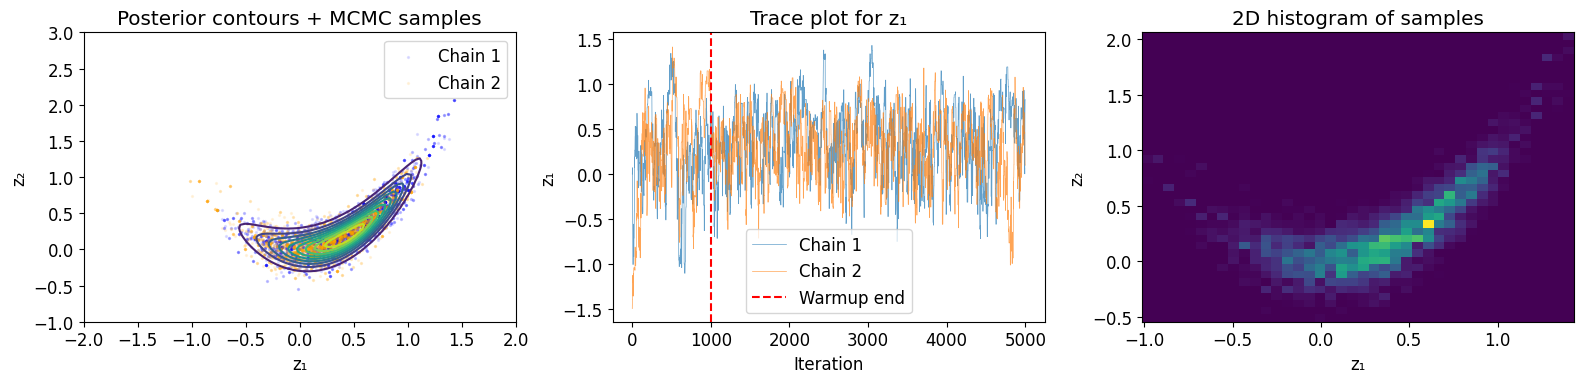

In [10]:
# Week 8 demo: metropolis-hastings sampler

def metropolis(log_target, theta_init, tau, n_iter, seed=42):
    """Metropolis algorithm with isotropic Gaussian proposal."""
    rng = np.random.default_rng(seed)
    D = len(theta_init)
    samples = np.zeros((n_iter, D))
    samples[0] = theta_init
    n_accept = 0
    
    for k in range(1, n_iter):
        theta_current = samples[k-1]
        theta_star    = theta_current + tau * rng.standard_normal(D)
        
        log_ratio = log_target(theta_star) - log_target(theta_current)
        if np.log(rng.uniform()) < log_ratio:
            samples[k] = theta_star
            n_accept += 1
        else:
            samples[k] = theta_current
    
    acceptance_rate = n_accept / n_iter
    return samples, acceptance_rate

# Target: 2D banana-shaped distribution (from 2024 exam!)
def log_target_banana(theta):
    z1, z2 = theta
    return -(1-z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2

n_iter = 5000
warmup = 1000

samples1, ar1 = metropolis(log_target_banana, np.array([0.0, 1.5]), tau=0.3, n_iter=n_iter, seed=0)
samples2, ar2 = metropolis(log_target_banana, np.array([-1.5, -0.5]), tau=0.3, n_iter=n_iter, seed=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Contour plot
z1g, z2g = np.meshgrid(np.linspace(-2,2,100), np.linspace(-1,3,100))
log_density = np.array([[log_target_banana([z1,z2]) for z1 in z1g[0]] for z2 in z2g[:,0]])
axes[0].contour(z1g, z2g, np.exp(log_density - log_density.max()), levels=10)
axes[0].scatter(*samples1[warmup:].T, alpha=0.1, s=2, c='blue', label='Chain 1')
axes[0].scatter(*samples2[warmup:].T, alpha=0.1, s=2, c='orange', label='Chain 2')
axes[0].legend(); axes[0].set_title('Posterior contours + MCMC samples')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')

# Trace plots
axes[1].plot(samples1[:, 0], lw=0.5, alpha=0.7, label='Chain 1')
axes[1].plot(samples2[:, 0], lw=0.5, alpha=0.7, label='Chain 2')
axes[1].axvline(warmup, color='r', linestyle='--', label='Warmup end')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('z₁')
axes[1].set_title('Trace plot for z₁'); axes[1].legend()

# Histogram after warmup
all_samples = np.vstack([samples1[warmup:], samples2[warmup:]])
axes[2].hist2d(all_samples[:,0], all_samples[:,1], bins=40, density=True)
axes[2].set_xlabel('z₁'); axes[2].set_ylabel('z₂')
axes[2].set_title('2D histogram of samples')

print(f'Acceptance rate chain 1: {ar1:.2f}')
print(f'Acceptance rate chain 2: {ar2:.2f}')
plt.tight_layout(); plt.show()

<a id='week9'></a>

<div class="alert alert-block alert-info">

### **Week 9**

MCMC theory, Hamiltonian Monte Carlo, the ULA/MALA algorithms, MCMC convergence diagnostics

</div>

=== Convergence Diagnostics ===
Well-mixed  chains → R-hat = 1.000  (should be ≈1.0)
Poorly-mixed chains → R-hat = 6.911  (should be >>1.0)

ESS for i.i.d. samples (S=1000): 1000  (≈1000)
ESS for correlated AR(1) chain:   53  (<<1000)


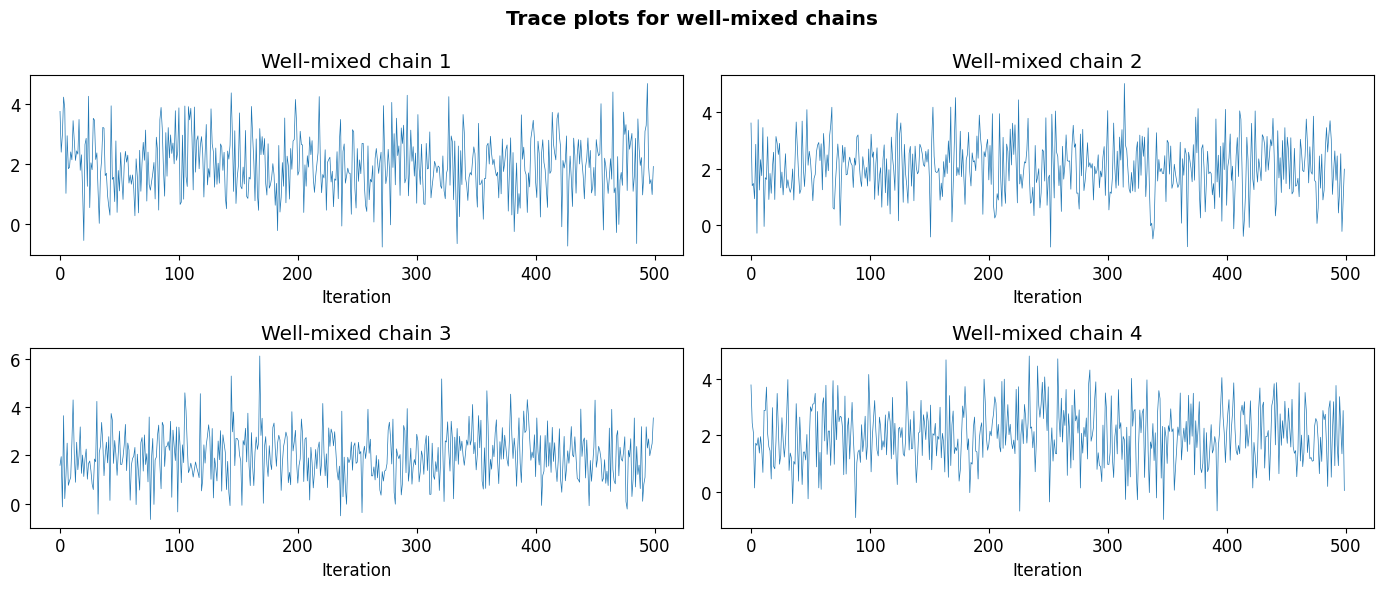

In [11]:
# Week 9 demo: convergence diagnostics - R-hat and ESS

def compute_rhat(chains):
    """Compute R-hat statistic. chains: shape (n_chains, n_samples)"""
    M, S = chains.shape
    chain_means = chains.mean(axis=1)          # (M,)
    grand_mean  = chains.mean()
    B = S / (M - 1) * np.sum((chain_means - grand_mean)**2)   # between-chain variance
    W = np.mean(np.var(chains, axis=1, ddof=1))                # within-chain variance
    R2 = (S-1)/S + (1/S) * (B/W)
    return np.sqrt(R2)

def compute_ess(samples):
    """Compute effective sample size for a 1D chain."""
    S = len(samples)
    rho_sum = 0
    for t in range(1, S):
        rho_t = np.corrcoef(samples[:-t], samples[t:])[0, 1]
        if rho_t < 0.05:  # stop when autocorrelation is negligible
            break
        rho_sum += rho_t
    return S / (1 + 2 * rho_sum)

# Compare: well-mixed vs. poorly-mixed chains
np.random.seed(42)

# Well-mixed: multiple chains from same distribution
good_chains = np.array([norm.rvs(loc=2, scale=1, size=500, random_state=i) for i in range(4)])

# Poorly mixed: chains stuck in different modes
poor_chains = np.vstack([
    np.array([norm.rvs(loc=-3, scale=0.5, size=500, random_state=0),
              norm.rvs(loc=-3, scale=0.5, size=500, random_state=1)]),
    np.array([norm.rvs(loc=+3, scale=0.5, size=500, random_state=2),
              norm.rvs(loc=+3, scale=0.5, size=500, random_state=3)])
])

print('=== Convergence Diagnostics ===')
print(f'Well-mixed  chains → R-hat = {compute_rhat(good_chains):.3f}  (should be ≈1.0)')
print(f'Poorly-mixed chains → R-hat = {compute_rhat(poor_chains):.3f}  (should be >>1.0)')
print()

# ESS for correlated vs. uncorrelated samples
iid_samples  = norm.rvs(0, 1, size=1000, random_state=0)
# AR(1) correlated chain
rho_ar = 0.9
ar1_samples = np.zeros(1000)
for t in range(1, 1000):
    ar1_samples[t] = rho_ar * ar1_samples[t-1] + np.sqrt(1-rho_ar**2) * np.random.randn()

ess_iid = compute_ess(iid_samples)
ess_ar1 = compute_ess(ar1_samples)
print(f'ESS for i.i.d. samples (S=1000): {ess_iid:.0f}  (≈1000)')
print(f'ESS for correlated AR(1) chain:   {ess_ar1:.0f}  (<<1000)')

# Trace plots
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for i in range(4):
    axes[i//2, i%2].plot(good_chains[i], lw=0.5)
    axes[i//2, i%2].set_title(f'Well-mixed chain {i+1}')
    axes[i//2, i%2].set_xlabel('Iteration')
fig.suptitle('Trace plots for well-mixed chains', fontweight='bold')
plt.tight_layout(); plt.show()

<a id='week10'></a>

<div class="alert alert-block alert-info">

### **Week 10 | Variational Inference & Mixture Models**

Variational inference, ELBO, KL divergence, mean-field approximation, CAVI, Gaussian mixture models, Dirichlet distribution
</div>

In [12]:
import numpy as np
from scipy.stats import norm

# Week 10 Demo: ELBO evaluation 
# 2024 exam Part 4 pattern:
# y | w1,w2 ~ N(w1*w2, 1),  w1,w2 ~ N(0,1),  y=1
# q(w) = N(w1|m1,v1) N(w2|m2,v2)

y_obs, sigma2 = 1.0, 1.0
m1, m2 = -1.0, 1.0
v1, v2 =  1.0, 1.0

# Expected log-likelihood  E_q[ln N(y | w1*w2, σ²)]
E_f   = m1 * m2
E_f2  = (m1**2 + v1) * (m2**2 + v2)   # E[f²] = E[w1²]·E[w2²]
E_sq_resid = y_obs**2 - 2*y_obs*E_f + E_f2
E_log_lik  = -0.5*np.log(2*np.pi*sigma2) - 0.5/sigma2 * E_sq_resid

# KL[N(m,v) ‖ N(0,1)] = ½(v + m² - 1 - ln v)
kl = lambda m, v: 0.5 * (v + m**2 - 1 - np.log(v))
KL_total = kl(m1, v1) + kl(m2, v2)

ELBO = E_log_lik - KL_total

# Entropy H[q] = Σ ½ ln(2πe v_i)
H_q = 0.5*np.log(2*np.pi*np.e*v1) + 0.5*np.log(2*np.pi*np.e*v2)

print(f'Expected log-likelihood : {E_log_lik:.4f}')
print(f'Total KL to prior       : {KL_total:.4f}')
print(f'ELBO                    : {ELBO:.4f}')
print(f'Entropy H[q]            : {H_q:.4f}')
print()
print('Mean-field Cov[w1,w2] = 0 by construction')
print('True posterior likely has strong neg. correlation (w1*w2≈1)')
print('=> switching to full-rank Q2 would improve the approximation')

Expected log-likelihood : -4.4189
Total KL to prior       : 1.0000
ELBO                    : -5.4189
Entropy H[q]            : 2.8379

Mean-field Cov[w1,w2] = 0 by construction
True posterior likely has strong neg. correlation (w1*w2≈1)
=> switching to full-rank Q2 would improve the approximation


<a id='week11'></a>

<div class="alert alert-block alert-info">

### **Week 11 | Black-box variational inference (BBVI)**

Free-form vs fixed-form VI, reparameterization trick, minibatching, VAEs, scaling GPs with inducing points

</div>

In [13]:
# Week 11 Demo: BBVI core loop (conceptual)
import jax.numpy as jnp
from jax import random, value_and_grad

def bbvi_elbo(lam, X, y, key, S=20, batch_size=None):
    """Estimate ELBO using reparameterization trick."""
    D = len(lam) // 2
    m, log_v = lam[:D], lam[D:]
    v = jnp.exp(log_v)
    
    # Reparameterization: w = m + sqrt(v) * eps, eps ~ N(0,I)
    key_eps, key_batch = random.split(key)
    eps = random.normal(key_eps, shape=(S, D))
    w_samples = m[None, :] + jnp.sqrt(v)[None, :] * eps   # shape: (S, D)
    
    # Log joint: E_q[log p(y,w)] ≈ (1/S) Σ_s log p(y, w^(s))
    # With minibatching:
    if batch_size:
        idx = random.choice(key_batch, len(y), shape=(batch_size,), replace=False)
        X_b, y_b = X[idx], y[idx]
        scale = len(y) / batch_size
        expected_log_lik = scale * jnp.mean(log_likelihood(X_b, y_b, w_samples))
    else:
        expected_log_lik = jnp.mean(log_likelihood(X, y, w_samples))
    
    expected_log_prior = jnp.mean(log_prior(w_samples))
    
    # Entropy H[q] = 0.5 * sum(log(2*pi*e*v_i))  -- analytical!
    entropy = 0.5 * jnp.sum(jnp.log(2 * jnp.pi * jnp.e * v))
    
    return expected_log_lik + expected_log_prior + entropy


# The key insight: log-prior and log-likelihood are all you need to implement.
# BBVI handles the rest automatically via autodiff on the reparameterized ELBO.
print("BBVI only requires: log_prior(w) and log_likelihood(X, y, w)")
print("No closed-form derivations needed! Just plug in and optimize.")

BBVI only requires: log_prior(w) and log_likelihood(X, y, w)
No closed-form derivations needed! Just plug in and optimize.


<a id='week12'></a>

<div class="alert alert-block alert-info">


### **Week 12 | Bayesian neural networks**

MAP inference, deep ensembles, last-layer Laplace approximation (LLLA), Monte Carlo dropout, mean-field BNNs, heteroscedastic models

</div>

In [14]:
import jax.numpy as jnp
from jax import random
from jax.scipy.stats import norm

# ── Heteroscedastic log-likelihood ──────────────────────────────────────
def log_lik_regression(X, y, w, nn_model):
    """
    nn_model outputs [mu, log_sigma^2] for each input.
    w: (S, D) array of weight samples
    Returns log-likelihood for each sample: shape (S,)
    """
    S = w.shape[0]
    log_liks = []
    for s in range(S):
        f = nn_model(X, w[s])          # shape: (N, 2)
        mu     = f[:, 0]               # predicted mean
        log_v  = f[:, 1]               # predicted log-variance
        v      = jnp.exp(log_v)
        log_liks.append(jnp.sum(norm.logpdf(y.ravel(), mu, jnp.sqrt(v))))
    return jnp.array(log_liks)


# ── Deep ensemble prediction ─────────────────────────────────────────────
def ensemble_predict(ensemble_models, x_star):
    """Predict with deep ensemble: returns mixture of Gaussians."""
    preds = [model.predict(x_star) for model in ensemble_models]
    # preds[i] = [mu_i, log_v_i]
    mus   = jnp.array([p[:, 0] for p in preds])    # (S, N*)
    vars_ = jnp.array([jnp.exp(p[:, 1]) for p in preds])  # (S, N*)
    # Predictive mean and variance of the mixture:
    mu_mix  = jnp.mean(mus, axis=0)
    var_mix = jnp.mean(vars_ + mus**2, axis=0) - mu_mix**2
    return mu_mix, var_mix


# ── Log predictive density (LPD) ─────────────────────────────────────────
def compute_lpd(y_test, mu_samples, var_samples):
    """
    Compute average LPD for ensemble predictions.
    mu_samples, var_samples: shape (S, N_test)
    """
    # p(y*|y,x*) ≈ (1/S) Σ_s N(y* | mu^(s), var^(s))
    S = mu_samples.shape[0]
    log_pdfs = norm.logpdf(y_test[None, :], mu_samples, jnp.sqrt(var_samples))  # (S, N)
    # log(1/S Σ exp(log_pdfs))  — use logsumexp for numerical stability
    from jax.scipy.special import logsumexp
    log_p = logsumexp(log_pdfs, axis=0) - jnp.log(S)    # (N,)
    return jnp.mean(log_p)


# ── LLLA posterior covariance (for linear last layer) ────────────────────
def compute_llla_covariance(Z, alpha, sigma2):
    """
    Z: (N, H) last-layer features
    alpha: prior precision
    sigma2: noise variance
    Returns S_L: (H, H) last-layer posterior covariance
    """
    H = Z.shape[1]
    S_inv = alpha * jnp.eye(H) + (1/sigma2) * Z.T @ Z
    return jnp.linalg.inv(S_inv)   # = S_L

print("LPD penalises both accuracy and calibration.")
print("MAP: single sample, no epistemic uncertainty.")
print("Ensemble: multiple samples via diversity of init.")
print("LLLA: single sample for all layers except last; last layer is Bayesian.")

LPD penalises both accuracy and calibration.
MAP: single sample, no epistemic uncertainty.
Ensemble: multiple samples via diversity of init.
LLLA: single sample for all layers except last; last layer is Bayesian.
